In [ ]:
import pandas as pd
import sklearn
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


df = pd.read_csv('E-commerce Customer Behavior - Sheet1.csv')

SUBSTASK 1: EDA & DATA PREPARATION
(1) Data Cleaning

outliers: Empty DataFrame
Columns: [Customer ID, Gender, Age, City, Membership Type, Total Spend, Items Purchased, Average Rating, Discount Applied, Days Since Last Purchase, Satisfaction Level]
Index: []


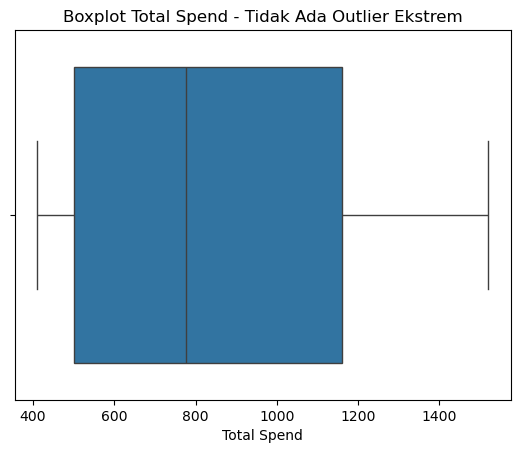

In [ ]:
df.isnull().sum()

Q1 = df['Total Spend'].quantile(0.25)
Q3 = df['Total Spend'].quantile(0.75)

IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

outliers = df[(df['Total Spend'] < batas_bawah) | (df['Total Spend'] > batas_atas)]
print("outliers:", outliers)

sns.boxplot(x=df['Total Spend'])
plt.title('Boxplot Total Spend - Tidak Ada Outlier Ekstrem')
plt.show()

Data bersih dari ouliers extreme dan semua pelanggan ada dalam batas wajar

SUBSTASK 1: EDA & DATA PREPARATION
(2)Feature Engineering

In [ ]:
df['Days Since Last Purchase'] = df['Days Since Last Purchase'].replace(0, 1)

Purchase_Intensity = df['Total Spend'] / df['Days Since Last Purchase']
df['Purchase_Intensity'] = Purchase_Intensity

df[['Purchase_Intensity']].head(10)


,Purchase_Intensity
0,44.808000
1,43.361111
2,12.160714
3,123.358333
4,13.098182
5,20.036364
6,41.092857
7,57.207143
8,12.381250
9,168.900000


SUBSTASK 1: EDA & DATA PREPARATION
(3) Standardization

In [ ]:
scaler = StandardScaler()
kolom_nomor = ['Age', 'Total Spend', 'Days Since Last Purchase', 'Purchase_Intensity', 'Items Purchased', 'Average Rating']
df[kolom_nomor] = scaler.fit_transform(df[kolom_nomor])
df.describe()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase,Purchase_Intensity
count,350.000000,3.500000e+02,3.500000e+02,3.500000e+02,3.500000e+02,3.500000e+02,3.500000e+02
mean,275.500000,2.023778e-16,1.126083e-16,8.390114e-17,-7.765217e-16,1.015061e-16,8.120488e-17
std,101.180532,1.001432e+00,1.001432e+00,1.001432e+00,1.001432e+00,1.001432e+00,1.001432e+00
min,101.000000,-1.561939e+00,-1.202026e+00,-1.349384e+00,-1.758026e+00,-1.310468e+00,-8.827596e-01
25%,188.250000,-7.395565e-01,-9.497723e-01,-8.674609e-01,-8.955237e-01,-8.634271e-01,-7.701335e-01
50%,275.500000,-2.255677e-01,-1.941182e-01,-1.445768e-01,1.394789e-01,-2.673729e-01,-3.535222e-01
75%,362.750000,6.996122e-01,8.718740e-01,5.783073e-01,8.294807e-01,8.502287e-01,2.792339e-01
max,450.000000,1.933185e+00,1.866228e+00,2.024075e+00,1.519482e+00,2.712898e+00,2.853735e+00


[Penjelasan mengapa Standarization penting sebelum clustering]Algoritma clustering seperti K-Means dan DBSCAN sangat bergantung pada jarak antar titik data. Jika fitur memiliki skala yang berbeda (misalnya Age 20–80 vs Total Spend ribuan), fitur dengan rentang lebih besar akan mendominasi perhitungan jarak. Standardisasi mengubah semua fitur ke rata-rata 0 dan deviasi 1, sehingga setiap fitur berkontribusi secara adil. Tanpa standardisasi, segmentasi akan bias terhadap fitur dengan nilai numerik besar.

Subtask 2: UNSUPERVISED LEARNING
(1)KMeans

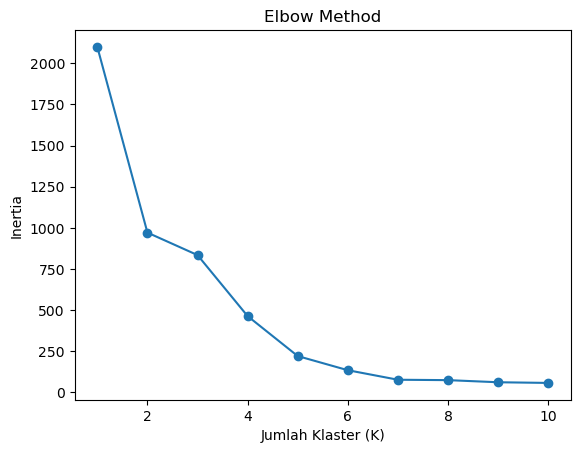

In [ ]:
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df[kolom_nomor])
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Inertia')
plt.show()

Cluster
1    175
3     59
2     58
0     58
Name: count, dtype: int64


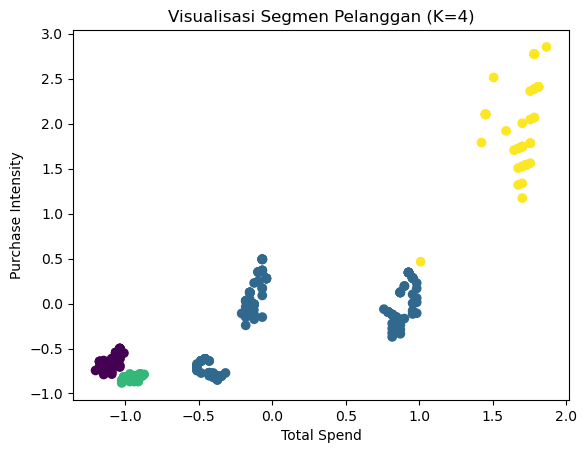

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
hasil_cluster = kmeans.fit_predict(df[kolom_nomor])
df['Cluster'] = hasil_cluster
print(df['Cluster'].value_counts())

plt.scatter(df['Total Spend'], df['Purchase_Intensity'], c=df['Cluster'], cmap='viridis')
plt.xlabel('Total Spend')
plt.ylabel('Purchase Intensity')
plt.title('Visualisasi Segmen Pelanggan (K=4)')
plt.show()

Subtask 2: UNSUPERVISED LEARNING
(2)DBScan

Cluster_DBSCAN
 0     58
 1     58
 4     58
 5     50
 2     24
 3     24
 6     24
 7     24
 8      9
 9      9
 10     8
-1      4
Name: count, dtype: int64


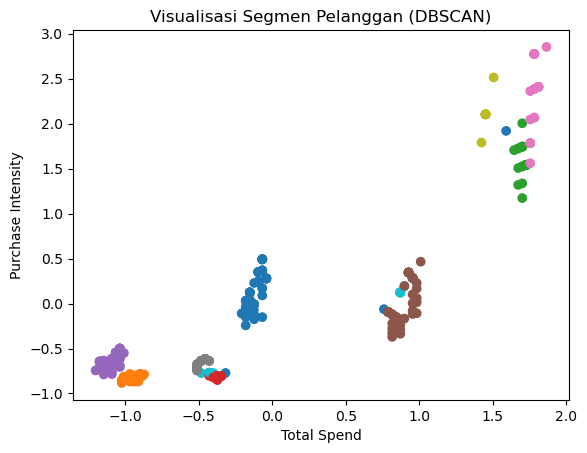

In [ ]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
Cluster_DBSCAN = dbscan.fit_predict(df[kolom_nomor])

df['Cluster_DBSCAN'] = dbscan.labels_
print(df['Cluster_DBSCAN'].value_counts())

plt.scatter(df['Total Spend'], df['Purchase_Intensity'], c=df['Cluster_DBSCAN'], cmap='tab10')
plt.xlabel('Total Spend')
plt.ylabel('Purchase Intensity')
plt.title('Visualisasi Segmen Pelanggan (DBSCAN)')
plt.show()

Subtask 2: UNSUPERVISED LEARNING
(3)Analisis Kritis

Untuk metode mana yang lebih efektif sebenarnya DBSCAN dan KMeans memiliki beberapa kelebihan dan kekuranganya sendriri [1]DBSCAN dia presisi untuk menentukan mana noise dan tidak tetapi untuk memilih target diskon DBSCAN bisa membuat data noise itu di abaikan karna jumlahnya sangat sedikit dan membuat terabaikan, lalu data yang noise terabaikan itu juga akan menjadi PR untuk tim promosi karna harus membuat banyak target diskon karna kelompoknya banyak dan sangat bervariasi [2] Disatu sisi KMeans memaksa data noise untuk masuk ke kelompok tersebut karna saya disini membuat KMeans agar menjadikan hanya 4 cluster jadi tim promosi lebih mudah menentukan target promosi diskon ke 4 cluster karna cluster di KMeans menarik yang terdekat dan jangkauanya lumayan luas jadi tidak terlalu banyak noise [KESIMPULAN] KMeans lebih efektif karna bisa membuat kelompok lebih rapih dan mempermudah menentukan target promosi sedangkan DBSCAN membuat tim promosi bekerja keras karna kelompoknya banyak jadi untuk keunggulan dan efektifitas memilih target promosi KMeans adalah pilihan yang tepat di kasus ini. 